In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scico
from scico import functional, linop, loss
from tqdm import tqdm
import numpy as np
import torch
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.metrics import structural_similarity as skimage_ssim
from utils import measure, load_dataset
from inverse_mayoct_tomo import get_operators

IMG_SIZE = 512
SPACE_RANGE = 128
NUM_ANGLES = 200
DET_SHAPE = 400


NOISE_STD = 2.0
DATA_ROOT = "./mayoct"

x_list = load_dataset(DATA_ROOT, "test")

In [7]:
fwd_op_numpy, adjoint_op_numpy, fbp_op_numpy = get_operators(
        SPACE_RANGE, IMG_SIZE, NUM_ANGLES, DET_SHAPE
    )

A = scico.linop.LinearOperator(
    input_shape=(IMG_SIZE, IMG_SIZE),
    output_shape=(NUM_ANGLES, DET_SHAPE),
    eval_fn=fwd_op_numpy,
    adj_fn=adjoint_op_numpy,
    input_dtype=np.float32,
    output_dtype=np.float32,
    jit=False,
)

In [8]:
import importlib
import lpn_512
importlib.reload(lpn_512)
from lpn_512 import LPN
mmse = LPN(in_dim=1, beta = 10)
mmse.load_state_dict(torch.load("results/model.pt", map_location="cuda", weights_only=True)["model_state_dict"])
mmse.eval()
mmse.to("cuda")

LPN(
  (lin): ModuleList(
    (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7-8): 2 x Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (9): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(1, 256, kernel_size=

In [9]:

# y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to("cuda")
# result = mmse(y_tensor).squeeze().detach().cpu().numpy()

In [10]:
def apply_mmse(xk):
    x_torch = torch.tensor(np.array(xk), dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()
    result = mmse(x_torch)
    return result.squeeze().detach().cpu().numpy()

100%|██████████| 10/10 [00:00<00:00, 37.13it/s]


Text(0, 0.5, '$\\min_{k \\leq K} \\| \\nabla F(x_k)\\|$')

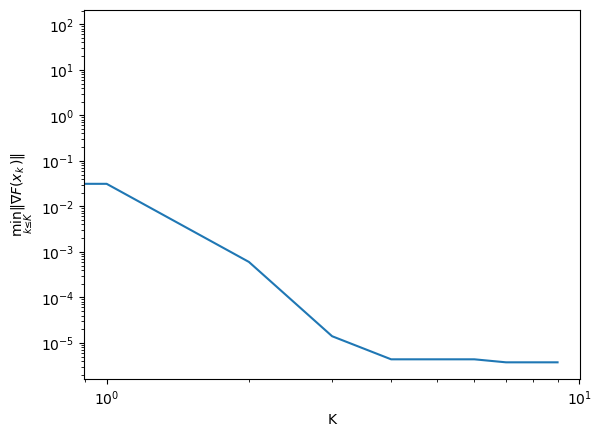

In [12]:
test = x_list[7]['image'][0]
Ax = A(test)
noise = np.random.normal(0, 1, Ax.shape).astype(np.float32)
y = Ax + 2 * noise
operator_norm = scico.linop.operator_norm(A)
xk = fbp_op_numpy(y)
grad_list = []
diff_list = []
for i in tqdm(range(10)):
    lastxk = xk
    xk = apply_mmse(xk - 1/(operator_norm+1)**2 * A.T(A(xk) - y))
    last_fgrad = 1/(operator_norm+1)**2 * A.T(A(lastxk) - y)
    next_fgrad = 1/(operator_norm+1)**2 * A.T(A(xk) - y)
    Fgrad = lastxk - xk + next_fgrad - last_fgrad
    grad_list.append(np.linalg.norm(Fgrad))
    diff_list.append(np.linalg.norm(xk - lastxk))
min_so_far = np.minimum.accumulate(grad_list)
plt.loglog([i for i in range(0,10)], min_so_far)
plt.xlabel("K")
plt.ylabel("$\min_{k \leq K} \| \\nabla F(x_k)\|$")

shape: (512, 512)
min: -0.00895058 max: 0.013922
unique values: 261877


/tmp/ipykernel_11943/1106430015.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x_torch = torch.tensor(np.array(xk), dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()


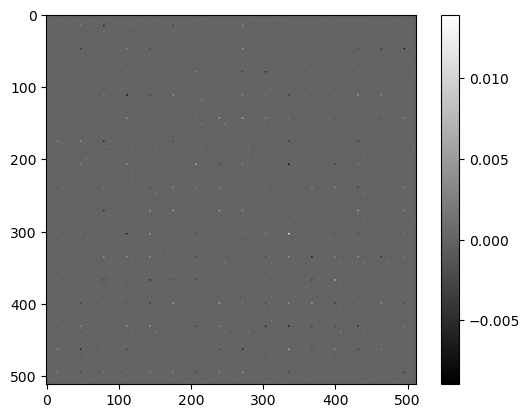

In [13]:
with torch.no_grad():
    output = apply_mmse(test)

# output is already a numpy array
print("shape:", output.shape)
print("min:", output.min(), "max:", output.max())
print("unique values:", len(np.unique(output)))

plt.imshow(output.squeeze(), cmap='gray', vmin=output.min(), vmax=output.max())
plt.colorbar()
plt.show()

In [ ]:
test

In [ ]:
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.loglog([i for i in range(1,1000)], np.minimum.accumulate(grad_list)[1::], label="$\displaystyle \min_{i \leq k} \| \\nabla F(x_i)\|$")
plt.loglog([i for i in range(1,1000)], np.minimum.accumulate(diff_list)[1::], label = "$\displaystyle \min_{i \leq k} \|x_{k+1}-x_k\|$")
plt.xlabel("$k$", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc="upper right",fontsize=12)
plt.savefig("ct_subgradient.pdf", format="pdf")

In [ ]:
plt.imshow(x_list[22]['image'].squeeze(),cmap="gray")

In [ ]:
from importlib import reload
import utils
reload(utils)
from utils import show_and_save_grid
clean_imgs = [x_list[0]['image'][0], x_list[13]['image'][0], x_list[22]['image'][0]]
Axs = [A(x) for x in clean_imgs]
noisy = [Ax + .2*np.random.normal(0, 1, Ax.shape).astype(np.float32) for Ax in Axs]
operator_norm = scico.linop.operator_norm(A)
denoised = []
j = 0
for y in noisy:
    xk = fbp_op_numpy(y)
    for i in tqdm(range(2)):
        yk = xk - 1/(operator_norm+1)**2 * A.T(A(xk) - y)
        xk = apply_mmse(yk)
    denoised.append(xk)
    j+=1
noisy_imgs = [fbp_op_numpy(y) for y in noisy]
show_and_save_grid(clean_imgs, noisy_imgs, denoised,  out_path="ct_denoise_light_noise.pdf")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xk, cmap="gray", vmin=test.min(), vmax=test.max())
axes[1].imshow(test, cmap="gray", vmin=test.min(), vmax=test.max())
axes[2].imshow(fbp_op_numpy(y), cmap="gray", vmin=test.min(), vmax=test.max())
plt.tight_layout()
plt.show()